**1. Emperical Distribution**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

   Marks  Empirical_Distribution
0     45                     0.1
8     50                     0.2
3     55                     0.3
1     60                     0.4
6     65                     0.5
2     70                     0.6
7     75                     0.7
4     80                     0.8
9     85                     0.9
5     90                     1.0


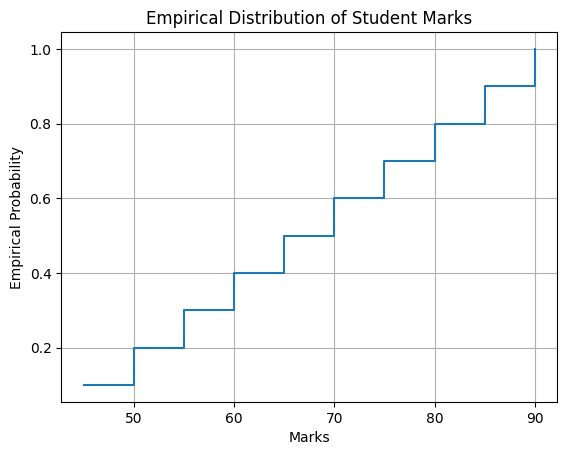

In [3]:
marks = [45, 60, 70, 55, 80, 90, 65, 75, 50, 85]

df = pd.DataFrame({"Marks": marks})

# Sort the values
df = df.sort_values("Marks")

# Calculate empirical distribution
df["Empirical_Distribution"] = (
    df["Marks"].rank(method="max") / len(df)
)

print(df)

# Plot Empirical Distribution
plt.step(
    df["Marks"],
    df["Empirical_Distribution"],
    where="post"
)

plt.xlabel("Marks")
plt.ylabel("Empirical Probability")
plt.title("Empirical Distribution of Student Marks")
plt.grid()
plt.show()

**2. Bernoli Distribution**

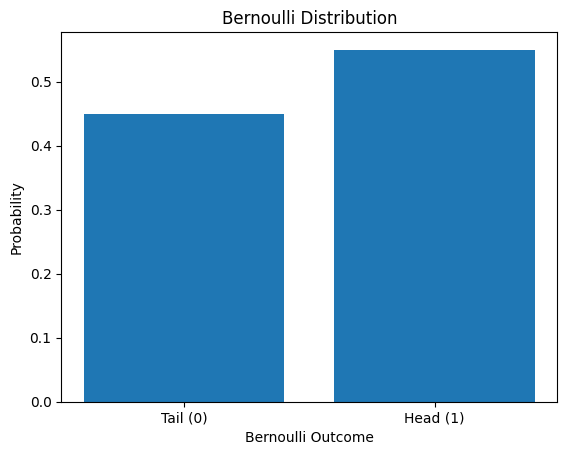

   Result  Bernoulli
0    Head          1
1    Tail          0
2    Head          1
3    Head          1
4    Tail          0
5    Head          1
6    Tail          0
7    Tail          0
8    Head          1
9    Head          1
10   Tail          0
11   Head          1
12   Tail          0
13   Head          1
14   Head          1
15   Tail          0
16   Head          1
17   Tail          0
18   Head          1
19   Tail          0


In [5]:
data = [
    "Head", "Tail", "Head", "Head", "Tail",
    "Head", "Tail", "Tail", "Head", "Head",
    "Tail", "Head", "Tail", "Head", "Head",
    "Tail", "Head", "Tail", "Head", "Tail"
]

df = pd.DataFrame({"Result": data})
df["Bernoulli"] = df["Result"].map({"Head": 1, "Tail": 0})
probability = df["Bernoulli"].value_counts(normalize=True).sort_index()

plt.bar(
    probability.index,
    probability.values
)

plt.xlabel("Bernoulli Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution")

plt.xticks([0, 1], ["Tail (0)", "Head (1)"])
plt.show()

print(df)

**3. Binoliam Distribution**

In [8]:
data = {
    "heads": np.random.binomial(10, 0.5, 1000)
}

df = pd.DataFrame(data)
probability = df["heads"].value_counts(normalize=True).sort_index()

print(probability)

heads
0     0.001
1     0.009
2     0.045
3     0.107
4     0.210
5     0.235
6     0.218
7     0.134
8     0.030
9     0.010
10    0.001
Name: proportion, dtype: float64


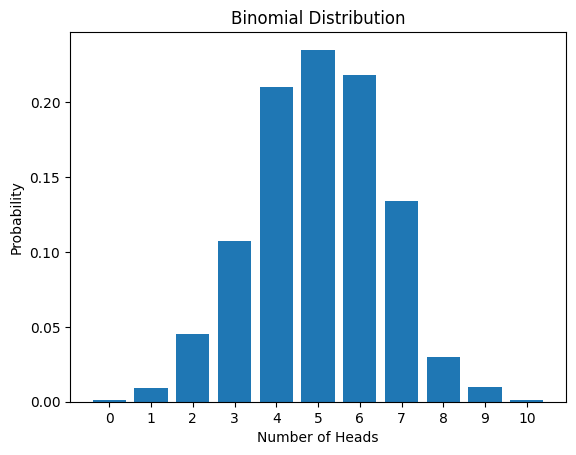

In [11]:
plt.bar(probability.index, probability.values)

plt.xlabel("Number of Heads")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.xticks(np.arange(0,11))
plt.show()

**4. Normal Distribution**

In [13]:
height = np.random.normal(170, 7, 100)

# Create DataFrame
df = pd.DataFrame({
    "Height": height
})

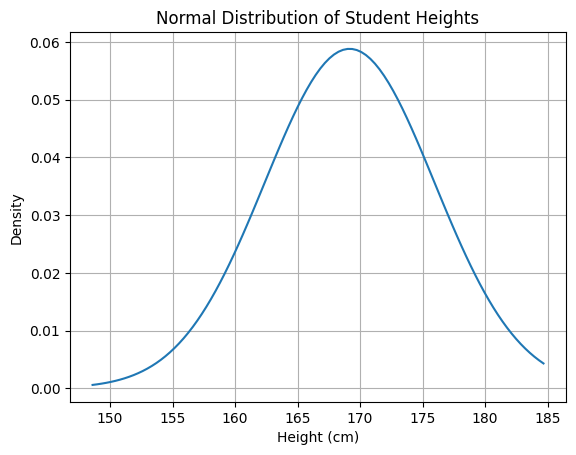

In [19]:
x = np.linspace(df["Height"].min(), df["Height"].max(), 100)

mean = df['Height'].mean()
std = df['Height'].std()

y = norm.pdf(x, mean, std)

plt.plot(x, y)

plt.xlabel("Height (cm)")
plt.ylabel("Density")
plt.title("Normal Distribution of Student Heights")
plt.grid(True)
plt.show()

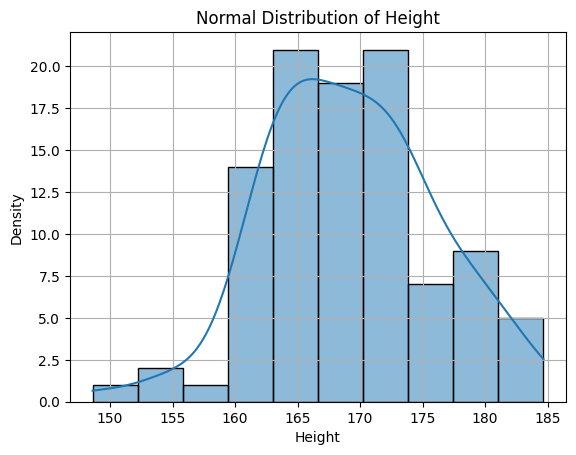

In [27]:
import seaborn as sns
sns.histplot(df["Height"],bins=10, kde=True)

plt.xlabel("Height")
plt.ylabel("Density")
plt.title("Normal Distribution of Height")
plt.grid(True)
plt.show()

**5. construct the join**

In [28]:
data = pd.DataFrame({
    "Gender": ["Male", "Female", "Male", "Female", "Male",
               "Female", "Male", "Female", "Male", "Female"],
    "Result": ["Pass", "Pass", "Fail", "Pass", "Pass",
               "Fail", "Fail", "Pass", "Pass", "Fail"]
})
data.head()

,Gender,Result
0,Male,Pass
1,Female,Pass
2,Male,Fail
3,Female,Pass
4,Male,Pass


In [39]:
join_table=pd.crosstab(data["Gender"], data["Result"])
join_table=join_table.reset_index()
join_table.columns.name = None
join_table.head()

,Gender,Fail,Pass
0,Female,2,3
1,Male,2,3


**6. Margibal Probability**

In [43]:
marginal_prob_gender=data['Gender'].value_counts(normalize=True)
print(marginal_prob_gender)

Gender
Male      0.5
Female    0.5
Name: proportion, dtype: float64


In [45]:
marginal_prob_result=data['Result'].value_counts(normalize=True)
print(marginal_prob_result)

Result
Pass    0.6
Fail    0.4
Name: proportion, dtype: float64


**7. Conditional Probability**

In [52]:
conditional = pd.crosstab(
    data["Gender"],
    data["Result"],
    normalize="index"
)
conditional=conditional.reset_index()
conditional.columns.name=None
print("Conditional Probability P(Result | Gender):")
conditional.head()

Conditional Probability P(Result | Gender):


,Gender,Fail,Pass
0,Female,0.4,0.6
1,Male,0.4,0.6


**8. Computing Prior Probability of each class**

In [66]:
data = pd.DataFrame({
    "Age": ["Young", "Young", "Middle", "Middle", "Old",
            "Old", "Young", "Middle", "Old", "Young"],
    
    "Membership": ["No", "No", "No", "Yes", "Yes",
                   "No", "Yes", "No", "Yes", "No"],
    
    "Buy": ["No", "Yes", "Yes", "Yes", "No",
            "No", "Yes", "Yes", "Yes", "No"]
})

In [67]:
data.head()

,Age,Membership,Buy
0,Young,No,No
1,Young,No,Yes
2,Middle,No,Yes
3,Middle,Yes,Yes
4,Old,Yes,No


In [68]:
prior_prob_age = data["Age"].value_counts(normalize=True)
prior_prob_age.head()

Age
Young     0.4
Middle    0.3
Old       0.3
Name: proportion, dtype: float64

In [69]:
prior_prob_membership = data["Membership"].value_counts(normalize=True)
prior_prob_membership.head()

Membership
No     0.6
Yes    0.4
Name: proportion, dtype: float64

In [70]:
prior_prob_buy = data["Buy"].value_counts(normalize=True)
prior_prob_buy.head()

Buy
Yes    0.6
No     0.4
Name: proportion, dtype: float64